In [53]:
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

### Load Data from Kaggle

In [54]:
DATA_PATH=Path('data/yahoo_stock.csv')
df=pd.read_csv(DATA_PATH)
df.head()

,Date,High,Low,Open,Close,Volume,Adj Close
0,2015-11-23,2095.610107,2081.389893,2089.409912,2086.590088,3.587980e+09,2086.590088
1,2015-11-24,2094.120117,2070.290039,2084.419922,2089.139893,3.884930e+09,2089.139893
2,2015-11-25,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
3,2015-11-26,2093.000000,2086.300049,2089.300049,2088.870117,2.852940e+09,2088.870117
4,2015-11-27,2093.290039,2084.129883,2088.820068,2090.110107,1.466840e+09,2090.110107


### Basic EDA (info, shape, etc )

In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1825 non-null   str    
 1   High       1825 non-null   float64
 2   Low        1825 non-null   float64
 3   Open       1825 non-null   float64
 4   Close      1825 non-null   float64
 5   Volume     1825 non-null   float64
 6   Adj Close  1825 non-null   float64
dtypes: float64(6), str(1)
memory usage: 99.9 KB


In [56]:
df.shape

(1825, 7)

In [57]:
df.isnull().sum()

Date         0
High         0
Low          0
Open         0
Close        0
Volume       0
Adj Close    0
dtype: int64

In [58]:
df.describe()

,High,Low,Open,Close,Volume,Adj Close
count,1825.000000,1825.000000,1825.000000,1825.000000,1.825000e+03,1825.000000
mean,2660.718673,2632.817580,2647.704751,2647.856284,3.869627e+09,2647.856284
std,409.680853,404.310068,407.169994,407.301177,1.087593e+09,407.301177
min,1847.000000,1810.099976,1833.400024,1829.079956,1.296540e+09,1829.079956
25%,2348.350098,2322.250000,2341.979980,2328.949951,3.257950e+09,2328.949951
50%,2696.250000,2667.840088,2685.489990,2683.340088,3.609740e+09,2683.340088
75%,2930.790039,2900.709961,2913.860107,2917.520020,4.142850e+09,2917.520020
max,3645.989990,3600.159912,3612.090088,3626.909912,9.044690e+09,3626.909912


In [59]:
df['Date']=pd.to_datetime(df['Date'], errors='coerce')

In [60]:
df['Date'].isna().sum()

np.int64(0)

In [61]:
(df['Date'].value_counts() > 2 ).sum()

np.int64(0)

<Axes: >

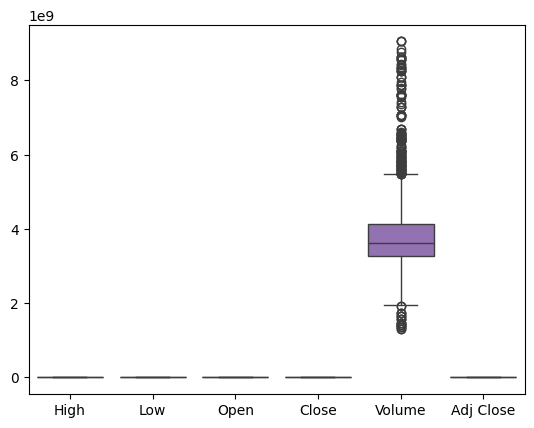

In [62]:
sns.boxplot(data=df)

<Axes: ylabel='Volume'>

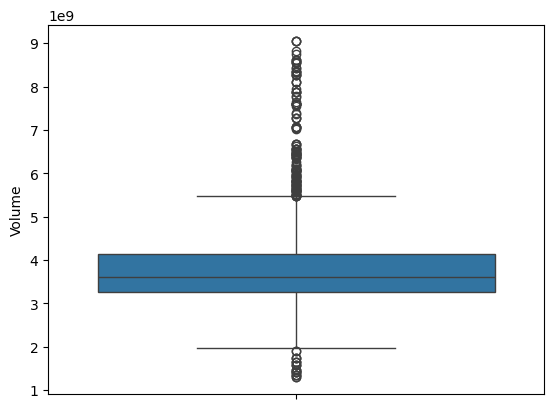

In [63]:
sns.boxplot(df['Volume']) # log_scale=True?

In [64]:
Q1=df['Volume'].quantile(0.25)
Q3=df['Volume'].quantile(0.75)
IQR=Q3-Q1
IQR

np.float64(884900000.0)

In [65]:
Q99=df['Volume'].quantile(0.99)
Q99

np.float64(8279190000.0)

<Axes: xlabel='Date', ylabel='Close'>

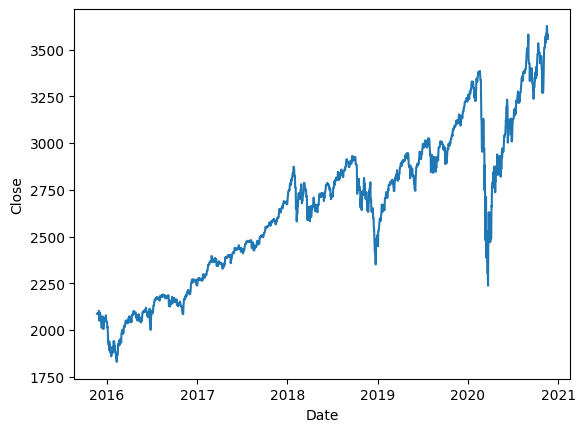

In [66]:
sns.lineplot(data=df,x='Date',y='Close')

<Axes: xlabel='Date', ylabel='Open'>

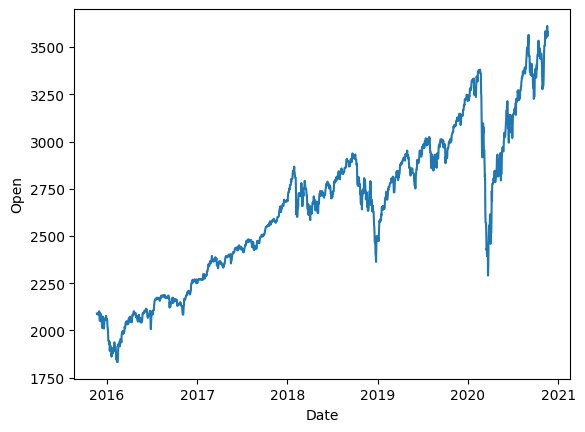

In [67]:
sns.lineplot(data=df,x='Date',y='Open')

<Axes: xlabel='Close', ylabel='Volume'>

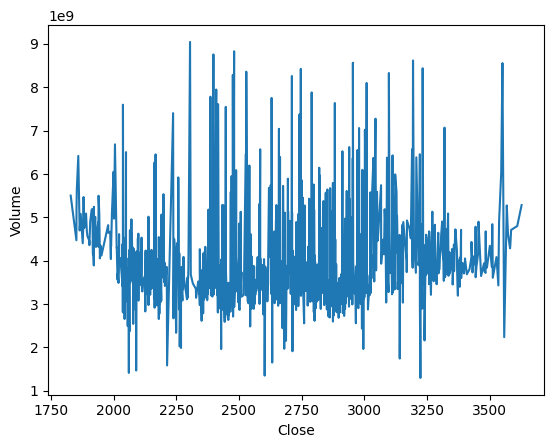

In [68]:
sns.lineplot(data=df,x='Close',y='Volume')

<Axes: xlabel='Open', ylabel='Volume'>

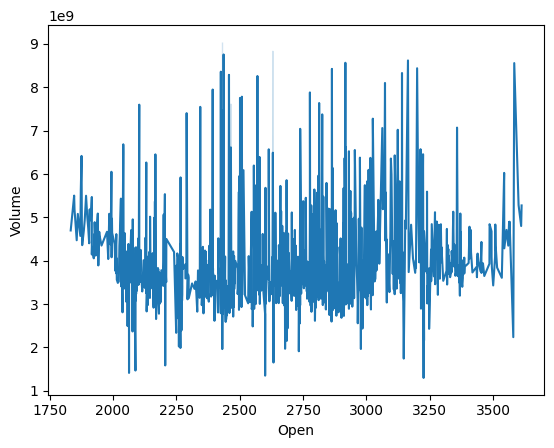

In [69]:
sns.lineplot(data=df,x='Open',y='Volume')

In [70]:
feature=df.select_dtypes(include='number')

<Axes: >

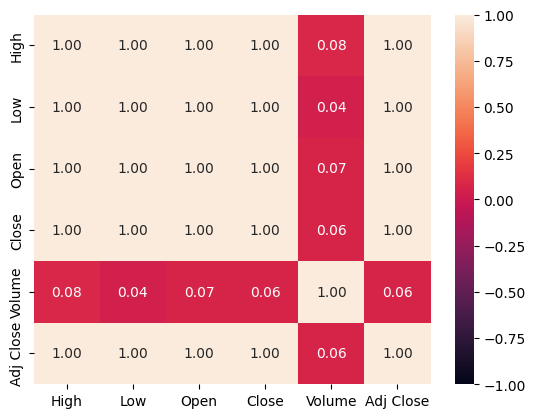

In [71]:
sns.heatmap(data=feature.corr(),vmax=1,vmin=-1,fmt='.2f',annot=True)